# 2D Heat Equation — FNO vs DeepONet

Both models learn the parameter-to-field operator:

$$\mathcal{G}: (T_L, T_R, T_B, T_T, T_{\text{init}}, \alpha, t) \;\mapsto\; u(\cdot,\cdot,t) \;\in\; \mathbb{R}^{32\times32}$$

| Model | Input | Output | Inductive bias |
|---|---|---|---|
| **FNO** | 5-channel 32×32 spatial field | 32×32 temperature field | 2D Fourier spectral convolution |
| **DeepONet** | 7 scalar parameters + (x,y) query | scalar temperature at (x,y) | Dot-product operator decomposition |

## 1. Imports & constants

In [6]:
from pathlib import Path
import copy
import time
import numpy as np
import pyarrow.parquet as pq
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from neuralop.models import FNO

device   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR = Path("dataset")
OUT_DIR  = Path("outputs"); OUT_DIR.mkdir(exist_ok=True)

NX = NY  = 32
T_SCALE  = 200.0    # normalise temperatures to ~ [0, 1]
ALPHA_MIN, ALPHA_MAX = 0.005, 0.05
T_MAX    = 30.0     # max time in dataset

print(f"Device : {device}")

Device : cuda


## 2. Data preparation → NPZ

Loads the pre-split Parquet files produced by `generate_heat2d_dataset.py`:

| Split | Cases | Rows | File |
|---|---|---|---|
| **Train** | 3 500 | 35 000 | `heat2d_train.parquet` |
| **Val** | 750 | 7 500 | `heat2d_val.parquet` |
| **Test** | 750 | 7 500 | `heat2d_test.parquet` |

Split is by `case_id` — all 10 time steps of a case stay in the same split (no leakage).

**FNO input** (5 channels, 32×32):
- Ch 0 `bc_field`: boundary temperatures on the 4 edges, initial temperature in the interior
- Ch 1 `alpha`: diffusivity broadcast across the grid
- Ch 2 `t`: time broadcast across the grid
- Ch 3 `x_grid`: x-coordinate field
- Ch 4 `y_grid`: y-coordinate field

**DeepONet branch input** (7 scalars): `[T_L, T_R, T_B, T_T, T_init, alpha, t]` normalised  
**DeepONet trunk input** (2 scalars per point): `(x, y)` — shared 1 024-point grid

All temperatures normalised by `T_SCALE = 200`.

In [ ]:
train_df = pq.read_table(DATA_DIR / "heat2d_train.parquet").to_pandas()
val_df   = pq.read_table(DATA_DIR / "heat2d_val.parquet").to_pandas()
test_df  = pq.read_table(DATA_DIR / "heat2d_test.parquet").to_pandas()

print(f"Loaded  train={len(train_df)}  val={len(val_df)}  test={len(test_df)}  rows")

x_grid = np.linspace(0, 1, NX, dtype=np.float32)
y_grid = np.linspace(0, 1, NY, dtype=np.float32)
X_GRID, Y_GRID = np.meshgrid(x_grid, y_grid, indexing='ij')  # (32, 32)

# All (x, y) pairs flattened — trunk input for DeepONet
trunk_xy = np.stack([X_GRID.ravel(), Y_GRID.ravel()], axis=1).astype(np.float32)  # (1024, 2)

def build_arrays(sub_df):
    N = len(sub_df)
    fno_X      = np.zeros((N, 5, NX, NY), dtype=np.float32)
    fno_Y      = np.zeros((N, 1, NX, NY), dtype=np.float32)
    don_params = np.zeros((N, 7),         dtype=np.float32)
    don_u      = np.zeros((N, NX * NY),   dtype=np.float32)

    for i, (_, row) in enumerate(sub_df.iterrows()):
        T_L, T_R = row["T_L"],  row["T_R"]
        T_B, T_T = row["T_B"],  row["T_T"]
        T_init   = row["T_init"]
        alpha, t = row["alpha"], row["t"]
        T_field  = np.array(row["T_field"], dtype=np.float32).reshape(NX, NY)

        # FNO: boundary-condition channel + coordinate channels
        bc = np.full((NX, NY), T_init / T_SCALE, dtype=np.float32)
        bc[0,  :]  = T_L / T_SCALE
        bc[-1, :]  = T_R / T_SCALE
        bc[:,  0]  = T_B / T_SCALE
        bc[:, -1]  = T_T / T_SCALE
        bc[0,  0]  = (T_L + T_B) / 2 / T_SCALE
        bc[0, -1]  = (T_L + T_T) / 2 / T_SCALE
        bc[-1, 0]  = (T_R + T_B) / 2 / T_SCALE
        bc[-1,-1]  = (T_R + T_T) / 2 / T_SCALE

        alpha_norm = (alpha - ALPHA_MIN) / (ALPHA_MAX - ALPHA_MIN)
        t_norm     = t / T_MAX

        fno_X[i, 0] = bc
        fno_X[i, 1] = alpha_norm
        fno_X[i, 2] = t_norm
        fno_X[i, 3] = X_GRID
        fno_X[i, 4] = Y_GRID
        fno_Y[i, 0] = T_field / T_SCALE

        # DeepONet
        don_params[i] = [
            T_L / T_SCALE, T_R / T_SCALE, T_B / T_SCALE,
            T_T / T_SCALE, T_init / T_SCALE,
            alpha_norm, t_norm,
        ]
        don_u[i] = T_field.ravel() / T_SCALE

    return fno_X, fno_Y, don_params, don_u

print("Building arrays …")
fno_X_tr, fno_Y_tr, don_p_tr, don_u_tr = build_arrays(train_df)
fno_X_va, fno_Y_va, don_p_va, don_u_va = build_arrays(val_df)
fno_X_te, fno_Y_te, don_p_te, don_u_te = build_arrays(test_df)

npz_path = DATA_DIR / "heat2d_training_data.npz"
np.savez(
    npz_path,
    fno_X_train=fno_X_tr, fno_Y_train=fno_Y_tr,
    fno_X_val=fno_X_va,   fno_Y_val=fno_Y_va,
    fno_X_test=fno_X_te,  fno_Y_test=fno_Y_te,
    don_params_train=don_p_tr, don_u_train=don_u_tr,
    don_params_val=don_p_va,   don_u_val=don_u_va,
    don_params_test=don_p_te,  don_u_test=don_u_te,
    trunk_xy=trunk_xy,
    x_grid=x_grid, y_grid=y_grid,
)
print(f"Saved → {npz_path}")
print(f"  FNO  train {fno_X_tr.shape}  val {fno_X_va.shape}  test {fno_X_te.shape}")
print(f"  DON  train params {don_p_tr.shape}  val {don_p_va.shape}  test {don_p_te.shape}")

## 3. Dataloaders

In [7]:
d = np.load(npz_path)

def tt(key): return torch.from_numpy(d[key])  # keep on CPU — too large for GPU all at once

# FNO tensors (CPU)
fno_Xtr, fno_Ytr = tt("fno_X_train"), tt("fno_Y_train")
fno_Xva, fno_Yva = tt("fno_X_val"),   tt("fno_Y_val")
fno_Xte, fno_Yte = tt("fno_X_test"),  tt("fno_Y_test")

# DeepONet tensors (CPU)
don_Ptr, don_Utr = tt("don_params_train"), tt("don_u_train")
don_Pva, don_Uva = tt("don_params_val"),   tt("don_u_val")
don_Pte, don_Ute = tt("don_params_test"),  tt("don_u_test")
TRUNK_XY         = tt("trunk_xy").to(device)  # small — stays on GPU

IS_CUDA = device.type == "cuda"
FNO_BATCH = 8 if IS_CUDA else 64
DON_BATCH = 128
EVAL_BATCH = 16 if IS_CUDA else 128  # keep inference bounded on smaller GPUs

fno_train_loader = DataLoader(
    TensorDataset(fno_Xtr, fno_Ytr), batch_size=FNO_BATCH,
    shuffle=True, pin_memory=IS_CUDA, num_workers=0,
)
don_train_loader = DataLoader(
    TensorDataset(don_Ptr, don_Utr), batch_size=DON_BATCH,
    shuffle=True, pin_memory=IS_CUDA, num_workers=0,
)

def predict_fno_batched(model, X):
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(X), EVAL_BATCH):
            xb = X[i:i+EVAL_BATCH].to(device, non_blocking=IS_CUDA)
            preds.append(model(xb).cpu())
    return torch.cat(preds, dim=0)

def predict_don_batched(model, P):
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(P), EVAL_BATCH):
            pb = P[i:i+EVAL_BATCH].to(device, non_blocking=IS_CUDA)
            preds.append(model(pb, TRUNK_XY).cpu())
    return torch.cat(preds, dim=0)

def eval_mse_fno(model, X, Y):
    """Batched MSE evaluation for FNO — avoids loading all tensors to GPU at once."""
    model.eval()
    total = 0.0
    with torch.no_grad():
        for i in range(0, len(X), EVAL_BATCH):
            xb = X[i:i+EVAL_BATCH].to(device, non_blocking=IS_CUDA)
            yb = Y[i:i+EVAL_BATCH].to(device, non_blocking=IS_CUDA)
            total += loss_fn(model(xb), yb).item() * len(xb)
    return total / len(X)

def eval_mse_don(model, P, U):
    """Batched MSE evaluation for DeepONet."""
    model.eval()
    total = 0.0
    with torch.no_grad():
        for i in range(0, len(P), EVAL_BATCH):
            pb = P[i:i+EVAL_BATCH].to(device, non_blocking=IS_CUDA)
            ub = U[i:i+EVAL_BATCH].to(device, non_blocking=IS_CUDA)
            total += loss_fn(model(pb, TRUNK_XY), ub).item() * len(pb)
    return total / len(P)

loss_fn = nn.MSELoss()

print(f"FNO  batches/epoch : {len(fno_train_loader)}")
print(f"DON  batches/epoch : {len(don_train_loader)}")
print(f"Shapes — FNO train: {tuple(fno_Xtr.shape)}  val: {tuple(fno_Xva.shape)}  test: {tuple(fno_Xte.shape)}")

FNO  batches/epoch : 4375
DON  batches/epoch : 274
Shapes — FNO train: (35000, 5, 32, 32)  val: (7500, 5, 32, 32)  test: (7500, 5, 32, 32)


## 4. FNO — model & training

In [8]:
FNO_MODES  = (12, 12)   # Fourier modes per spatial dim (max=16 for 32-pt grid)
FNO_HIDDEN = 32         # hidden channels — kept modest to fit GPU memory constraints
FNO_LAYERS = 4

fno_model = FNO(
    n_modes         = FNO_MODES,
    in_channels     = 5,
    out_channels    = 1,
    hidden_channels = FNO_HIDDEN,
    n_layers        = FNO_LAYERS,
).to(device)

fno_params = sum(p.numel() for p in fno_model.parameters() if p.requires_grad)
print(f"FNO parameters: {fno_params:,}")

FNO parameters: 357,473


In [9]:
EPOCHS    = 200
LR        = 1e-3
VAL_EVERY = 10

fno_opt   = torch.optim.Adam(fno_model.parameters(), lr=LR, weight_decay=1e-4)
fno_sched = torch.optim.lr_scheduler.CosineAnnealingLR(fno_opt, T_max=EPOCHS)

fno_train_hist, fno_val_hist = [], []
best_fno_val, best_fno_state = float("inf"), None
t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    fno_model.train()
    ep_loss = 0.0
    for X_b, Y_b in fno_train_loader:
        X_b = X_b.to(device, non_blocking=IS_CUDA)
        Y_b = Y_b.to(device, non_blocking=IS_CUDA)
        fno_opt.zero_grad(set_to_none=True)
        loss = loss_fn(fno_model(X_b), Y_b)
        loss.backward()
        fno_opt.step()
        ep_loss += loss.item() * len(X_b)
    ep_loss /= len(fno_Xtr)
    fno_train_hist.append(ep_loss)
    fno_sched.step()

    if epoch % VAL_EVERY == 0 or epoch == 1:
        val_loss = eval_mse_fno(fno_model, fno_Xva, fno_Yva)
        fno_val_hist.append((epoch, val_loss))
        if val_loss < best_fno_val:
            best_fno_val   = val_loss
            best_fno_state = copy.deepcopy(fno_model.state_dict())
        print(f"[FNO] epoch {epoch:>3}/{EPOCHS}  train={ep_loss:.4e}  val={val_loss:.4e}  lr={fno_sched.get_last_lr()[0]:.2e}")

fno_time = time.time() - t0
fno_model.load_state_dict(best_fno_state)
torch.save({"state_dict": best_fno_state, "val_loss": best_fno_val}, OUT_DIR / "fno_heat2d.pt")
print(f"\nFNO training done in {fno_time:.1f}s  best val MSE={best_fno_val:.4e}")

[FNO] epoch   1/200  train=1.2770e-02  val=3.9500e-03  lr=1.00e-03
[FNO] epoch  10/200  train=2.1723e-03  val=2.4211e-03  lr=9.94e-04
[FNO] epoch  20/200  train=1.9258e-03  val=1.6406e-03  lr=9.76e-04
[FNO] epoch  30/200  train=1.5918e-03  val=1.9589e-03  lr=9.46e-04
[FNO] epoch  40/200  train=1.3684e-03  val=1.2708e-03  lr=9.05e-04
[FNO] epoch  50/200  train=1.3197e-03  val=1.4273e-03  lr=8.54e-04
[FNO] epoch  60/200  train=1.2834e-03  val=1.5259e-03  lr=7.94e-04
[FNO] epoch  70/200  train=1.2363e-03  val=1.5468e-03  lr=7.27e-04
[FNO] epoch  80/200  train=1.2018e-03  val=1.0816e-03  lr=6.55e-04
[FNO] epoch  90/200  train=1.1642e-03  val=1.1233e-03  lr=5.78e-04
[FNO] epoch 100/200  train=1.1266e-03  val=1.0515e-03  lr=5.00e-04
[FNO] epoch 110/200  train=1.0825e-03  val=1.0834e-03  lr=4.22e-04
[FNO] epoch 120/200  train=1.0395e-03  val=9.8741e-04  lr=3.45e-04
[FNO] epoch 130/200  train=9.9507e-04  val=9.3229e-04  lr=2.73e-04
[FNO] epoch 140/200  train=9.5569e-04  val=9.4473e-04  lr=2.06

## 5. DeepONet — model & training

In [10]:
def _mlp(in_dim: int, width: int, depth: int, out_dim: int) -> nn.Sequential:
    layers = [nn.Linear(in_dim, width), nn.Tanh()]
    for _ in range(depth - 1):
        layers += [nn.Linear(width, width), nn.Tanh()]
    layers.append(nn.Linear(width, out_dim))
    return nn.Sequential(*layers)


class DeepONet2D(nn.Module):
    """
    DeepONet for 2D heat equation.
    Branch: (batch, 7 params) → (batch, p)
    Trunk:  (N_pts, 2 coords) → (N_pts, p)  [shared across batch]
    Output: branch @ trunk.T + bias  → (batch, N_pts)
    """
    def __init__(self, param_dim: int = 7, p: int = 128, width: int = 256, depth: int = 3):
        super().__init__()
        self.branch = _mlp(param_dim, width, depth, p)
        self.trunk  = _mlp(2,         width, depth, p)   # (x,y) → p
        self.bias   = nn.Parameter(torch.zeros(1))

    def forward(self, params: torch.Tensor, xy: torch.Tensor) -> torch.Tensor:
        b = self.branch(params)            # (B, p)
        t = torch.tanh(self.trunk(xy))     # (N_pts, p)  — tanh keeps trunk orthogonal
        return torch.einsum("bp,np->bn", b, t) + self.bias  # (B, N_pts)


don_model  = DeepONet2D(param_dim=7, p=128, width=256, depth=3).to(device)
don_params_count = sum(p.numel() for p in don_model.parameters() if p.requires_grad)
print(f"DeepONet parameters: {don_params_count:,}")

DeepONet parameters: 331,777


In [11]:
don_opt   = torch.optim.Adam(don_model.parameters(), lr=LR, weight_decay=1e-4)
don_sched = torch.optim.lr_scheduler.CosineAnnealingLR(don_opt, T_max=EPOCHS)

don_train_hist, don_val_hist = [], []
best_don_val, best_don_state = float("inf"), None
t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    don_model.train()
    ep_loss = 0.0
    for params_b, u_b in don_train_loader:
        params_b, u_b = params_b.to(device), u_b.to(device)
        don_opt.zero_grad(set_to_none=True)
        pred = don_model(params_b, TRUNK_XY)  # (B, 1024)
        loss = loss_fn(pred, u_b)
        loss.backward()
        don_opt.step()
        ep_loss += loss.item() * len(params_b)
    ep_loss /= len(don_Ptr)
    don_train_hist.append(ep_loss)
    don_sched.step()

    if epoch % VAL_EVERY == 0 or epoch == 1:
        val_loss = eval_mse_don(don_model, don_Pva, don_Uva)
        don_val_hist.append((epoch, val_loss))
        if val_loss < best_don_val:
            best_don_val   = val_loss
            best_don_state = copy.deepcopy(don_model.state_dict())
        print(f"[DON] epoch {epoch:>3}/{EPOCHS}  train={ep_loss:.4e}  val={val_loss:.4e}  lr={don_sched.get_last_lr()[0]:.2e}")

don_time = time.time() - t0
don_model.load_state_dict(best_don_state)
torch.save({"state_dict": best_don_state, "val_loss": best_don_val}, OUT_DIR / "don_heat2d.pt")
print(f"\nDeepONet training done in {don_time:.1f}s  best val MSE={best_don_val:.4e}")

[DON] epoch   1/200  train=2.9894e-02  val=1.6887e-02  lr=1.00e-03
[DON] epoch  10/200  train=5.6400e-03  val=5.3750e-03  lr=9.94e-04
[DON] epoch  20/200  train=5.0696e-03  val=5.1531e-03  lr=9.76e-04
[DON] epoch  30/200  train=4.7606e-03  val=4.7398e-03  lr=9.46e-04
[DON] epoch  40/200  train=4.5934e-03  val=4.4834e-03  lr=9.05e-04
[DON] epoch  50/200  train=4.4355e-03  val=4.9906e-03  lr=8.54e-04
[DON] epoch  60/200  train=4.2951e-03  val=4.1743e-03  lr=7.94e-04
[DON] epoch  70/200  train=4.2826e-03  val=4.1212e-03  lr=7.27e-04
[DON] epoch  80/200  train=4.2527e-03  val=4.4808e-03  lr=6.55e-04
[DON] epoch  90/200  train=4.2302e-03  val=4.1634e-03  lr=5.78e-04
[DON] epoch 100/200  train=4.1849e-03  val=4.2757e-03  lr=5.00e-04
[DON] epoch 110/200  train=4.1833e-03  val=4.1580e-03  lr=4.22e-04
[DON] epoch 120/200  train=4.1653e-03  val=4.2102e-03  lr=3.45e-04
[DON] epoch 130/200  train=4.1430e-03  val=4.1077e-03  lr=2.73e-04
[DON] epoch 140/200  train=4.1186e-03  val=4.0865e-03  lr=2.06

## 6. Analytical baseline

Recompute the analytical solution (same Fourier-series solver used to generate the dataset)
for every test record. This acts as the accuracy ceiling — any residual error here is
purely truncation noise from the finite series, not modelling error.

In [12]:
Lx, Ly = 1.0, 1.0
FINE_A  = 256
M_A = N_A = 20
N_STEADY_A = 40

_xo = np.linspace(0, Lx, NX); _yo = np.linspace(0, Ly, NY)
_xf = np.linspace(0, Lx, FINE_A); _yf = np.linspace(0, Ly, FINE_A)

_ma = np.arange(1, M_A + 1); _na = np.arange(1, N_A + 1)
_smxo = np.sin(np.outer(_ma * np.pi / Lx, _xo))  # (M, NX)
_snyo = np.sin(np.outer(_na * np.pi / Ly, _yo))  # (N, NY)
_smxf = np.sin(np.outer(_ma * np.pi / Lx, _xf))  # (M, FINE)
_snyf = np.sin(np.outer(_na * np.pi / Ly, _yf))  # (N, FINE)
_lsq  = (_ma[:, None] * np.pi / Lx)**2 + (_na[None, :] * np.pi / Ly)**2

_wx = np.ones(FINE_A); _wx[0] = _wx[-1] = 0.5; _wx *= Lx / (FINE_A - 1)
_wy = np.ones(FINE_A); _wy[0] = _wy[-1] = 0.5; _wy *= Ly / (FINE_A - 1)

# Precompute steady-state sin/sinh bases — vectorized over all k at once
_k_ss  = np.arange(1, 2 * N_STEADY_A, 2, dtype=np.float64)  # odd terms
_c_ss  = 4.0 / (_k_ss * np.pi)
_kx_ss = _k_ss * np.pi / Lx;  _aLy = _kx_ss * Ly
_ky_ss = _k_ss * np.pi / Ly;  _aLx = _ky_ss * Lx

def _sr(num, den):
    large = den > 15.0
    with np.errstate(over="ignore", invalid="ignore"):
        r = np.sinh(num) / np.where(large, 1.0, np.sinh(np.where(large, 1.0, den)))
    return np.where(large, np.exp(num - den), r)

# Fine-grid steady bases
_skx_f  = np.sin(np.outer(_kx_ss, _xf))                                        # (K, FINE)
_sb_f   = _sr(_kx_ss[:, None] * (Ly - _yf), _aLy[:, None] * np.ones(FINE_A))  # (K, FINE) bottom
_st_f   = _sr(_kx_ss[:, None] * _yf,         _aLy[:, None] * np.ones(FINE_A)) # (K, FINE) top
_sky_f  = np.sin(np.outer(_ky_ss, _yf))                                         # (K, FINE)
_sl_f   = _sr(_ky_ss[:, None] * (Lx - _xf), _aLx[:, None] * np.ones(FINE_A)) # (K, FINE) left
_sr_f   = _sr(_ky_ss[:, None] * _xf,         _aLx[:, None] * np.ones(FINE_A)) # (K, FINE) right

# Output-grid steady bases
_skx_o  = np.sin(np.outer(_kx_ss, _xo))
_sb_o   = _sr(_kx_ss[:, None] * (Ly - _yo), _aLy[:, None] * np.ones(NX))
_st_o   = _sr(_kx_ss[:, None] * _yo,         _aLy[:, None] * np.ones(NX))
_sky_o  = np.sin(np.outer(_ky_ss, _yo))
_sl_o   = _sr(_ky_ss[:, None] * (Lx - _xo), _aLx[:, None] * np.ones(NY))
_sr_o   = _sr(_ky_ss[:, None] * _xo,         _aLx[:, None] * np.ones(NY))

def _steady_vec(TL, TR, TB, TT, skx, sb, st, sky, sl, sr):
    """Vectorized steady-state: (Nx, K) @ (K, Ny) matrix multiplications."""
    u = np.zeros((skx.shape[1], sb.shape[1]))
    if TB: u += TB * (_c_ss[:, None] * skx).T @ sb
    if TT: u += TT * (_c_ss[:, None] * skx).T @ st
    if TL: u += TL * sl.T @ (_c_ss[:, None] * sky)
    if TR: u += TR * sr.T @ (_c_ss[:, None] * sky)
    return u

def analytical_field(t_values, T_L, T_R, T_B, T_T, T_init, alpha):
    """Vectorized analytical 2D heat solution on NX×NY grid. Returns (T, NX, NY) in °C."""
    tL, tR, tB, tT = T_L-T_init, T_R-T_init, T_B-T_init, T_T-T_init
    us_f  = _steady_vec(tL, tR, tB, tT, _skx_f, _sb_f, _st_f, _sky_f, _sl_f, _sr_f)
    fn    = (-us_f) @ (_snyf * _wy).T
    C     = _smxf @ (fn * _wx[:, None]) * (4.0 / (Lx * Ly))
    us_o  = _steady_vec(tL, tR, tB, tT, _skx_o, _sb_o, _st_o, _sky_o, _sl_o, _sr_o)
    out   = []
    for t in t_values:
        v = _smxo.T @ (C * np.exp(-alpha * _lsq * t)) @ _snyo
        out.append(T_init + us_o + v)
    return np.stack(out, axis=0)  # (T, NX, NY)

# Compute for every test record
ana_pred_C = np.zeros((len(test_df), NX, NY), dtype=np.float32)
t0_ana = time.time()

for cid, grp in test_df.groupby("case_id"):
    r0 = grp.iloc[0]
    U  = analytical_field(
        grp["t"].values,
        float(r0.T_L), float(r0.T_R), float(r0.T_B), float(r0.T_T),
        float(r0.T_init), float(r0.alpha),
    )
    for j, idx in enumerate(grp.index):
        ana_pred_C[idx] = U[j]

ana_time = time.time() - t0_ana
n_test_cases = test_df["case_id"].nunique()
print(f"Analytical: {len(test_df)} records ({n_test_cases} cases) in {ana_time:.1f}s  "
      f"({ana_time/n_test_cases*1000:.1f} ms/case)")

Analytical: 7500 records (750 cases) in 3.2s  (4.3 ms/case)


In [13]:
fno_model.eval(); don_model.eval()

with torch.no_grad():
    fno_pred_te = predict_fno_batched(fno_model, fno_Xte).squeeze(1).numpy()
    don_pred_te = predict_don_batched(don_model, don_Pte).numpy()

fno_true_te = fno_Yte.squeeze(1).cpu().numpy()
don_true_te = don_Ute.cpu().numpy()

# Denormalise → °C
fno_pred_C = fno_pred_te * T_SCALE
fno_true_C = fno_true_te * T_SCALE
don_pred_C = don_pred_te.reshape(-1, NX, NY) * T_SCALE
don_true_C = don_true_te.reshape(-1, NX, NY) * T_SCALE
# ana_pred_C already in °C (from previous cell)
ana_true_C = fno_true_C   # ground truth is the same for all three

def metrics(pred, true, label=""):
    """pred, true: (N, NX, NY) in °C."""
    mse     = np.mean((pred - true)**2)
    flat_p  = pred.reshape(len(pred), -1)
    flat_t  = true.reshape(len(true), -1)
    rel_l2  = np.linalg.norm(flat_p - flat_t, axis=1) / (np.linalg.norm(flat_t, axis=1) + 1e-8)
    return mse, rel_l2.mean(), rel_l2.std(), np.abs(pred - true).max(), rel_l2

fno_mse, fno_rel, fno_std, fno_max, fno_rel_all = metrics(fno_pred_C, fno_true_C)
don_mse, don_rel, don_std, don_max, don_rel_all = metrics(don_pred_C, don_true_C)
ana_mse, ana_rel, ana_std, ana_max, ana_rel_all = metrics(ana_pred_C, ana_true_C)

print("╔══════════════════════╦═══════════╦═══════════╦═══════════╗")
print("║ Metric               ║    FNO    ║  DeepONet ║ Analytical║")
print("╠══════════════════════╬═══════════╬═══════════╬═══════════╣")
print(f"║ Parameters           ║ {fno_params:>9,} ║ {don_params_count:>9,} ║ {'exact':>9} ║")
print(f"║ Training time (s)    ║ {fno_time:>9.1f} ║ {don_time:>9.1f} ║ {ana_time:>9.1f} ║")
print(f"║ Test MSE (°C²)       ║ {fno_mse:>9.4f} ║ {don_mse:>9.4f} ║ {ana_mse:>9.4f} ║")
print(f"║ Rel L2 (mean)        ║ {fno_rel:>9.4f} ║ {don_rel:>9.4f} ║ {ana_rel:>9.4f} ║")
print(f"║ Rel L2 (std)         ║ {fno_std:>9.4f} ║ {don_std:>9.4f} ║ {ana_std:>9.4f} ║")
print(f"║ Max abs error (°C)   ║ {fno_max:>9.4f} ║ {don_max:>9.4f} ║ {ana_max:>9.4f} ║")
print("╚══════════════════════╩═══════════╩═══════════╩═══════════╝")
print("\nNote: Analytical error vs ground truth is the Fourier-series truncation floor.")
print(f"      Neural networks are {fno_rel/ana_rel:.1f}× (FNO) and {don_rel/ana_rel:.1f}× (DON) above that floor.")

╔══════════════════════╦═══════════╦═══════════╦═══════════╗
║ Metric               ║    FNO    ║  DeepONet ║ Analytical║
╠══════════════════════╬═══════════╬═══════════╬═══════════╣
║ Parameters           ║   357,473 ║   331,777 ║     exact ║
║ Training time (s)    ║   15095.2 ║     319.3 ║       3.2 ║
║ Test MSE (°C²)       ║   33.0315 ║  157.6969 ║    0.0000 ║
║ Rel L2 (mean)        ║    0.0717 ║    0.1543 ║    0.0000 ║
║ Rel L2 (std)         ║    0.0430 ║    0.1032 ║    0.0000 ║
║ Max abs error (°C)   ║  107.6739 ║  223.5304 ║    0.0000 ║
╚══════════════════════╩═══════════╩═══════════╩═══════════╝

Note: Analytical error vs ground truth is the Fourier-series truncation floor.
      Neural networks are 1566822.0× (FNO) and 3371554.2× (DON) above that floor.


## 7. Comparison

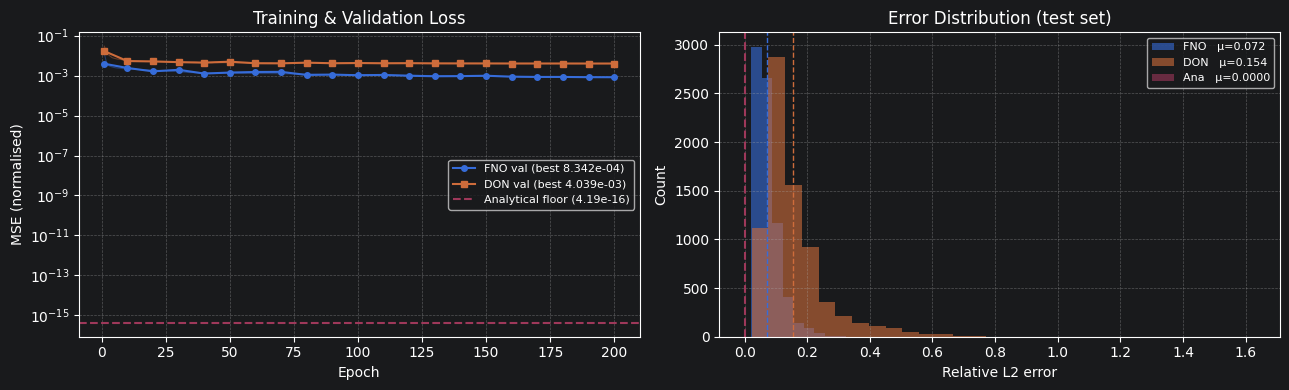

In [14]:
# --- Training curves + analytical floor ---
fno_val_ep, fno_val_mse = zip(*fno_val_hist)
don_val_ep, don_val_mse = zip(*don_val_hist)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.semilogy(range(1, EPOCHS+1), fno_train_hist, lw=0.8, alpha=0.4, color='C0')
ax.semilogy(fno_val_ep, fno_val_mse, 'o-', ms=4, lw=1.5, color='C0', label=f'FNO val (best {best_fno_val:.3e})')
ax.semilogy(range(1, EPOCHS+1), don_train_hist, lw=0.8, alpha=0.4, color='C1')
ax.semilogy(don_val_ep, don_val_mse, 's-', ms=4, lw=1.5, color='C1', label=f'DON val (best {best_don_val:.3e})')
# Analytical floor: MSE in normalised units
ana_mse_norm = np.mean(((ana_pred_C - ana_true_C) / T_SCALE)**2)
ax.axhline(ana_mse_norm, color='C2', ls='--', lw=1.5, label=f'Analytical floor ({ana_mse_norm:.2e})')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (normalised)')
ax.set_title('Training & Validation Loss'); ax.legend(fontsize=8)
ax.grid(True, which='both', ls='--', alpha=0.4)

ax = axes[1]
ax.hist(fno_rel_all, bins=30, alpha=0.6, color='C0', label=f'FNO   μ={fno_rel:.3f}')
ax.hist(don_rel_all, bins=30, alpha=0.6, color='C1', label=f'DON   μ={don_rel:.3f}')
ax.hist(ana_rel_all, bins=30, alpha=0.6, color='C2', label=f'Ana   μ={ana_rel:.4f}')
ax.axvline(fno_rel, color='C0', ls='--', lw=1)
ax.axvline(don_rel, color='C1', ls='--', lw=1)
ax.axvline(ana_rel, color='C2', ls='--', lw=1.5)
ax.set_xlabel('Relative L2 error'); ax.set_ylabel('Count')
ax.set_title('Error Distribution (test set)'); ax.legend(fontsize=8)
ax.grid(True, ls='--', alpha=0.4)

plt.tight_layout()
plt.savefig(OUT_DIR / 'heat2d_compare_curves.png', dpi=120)
plt.show()

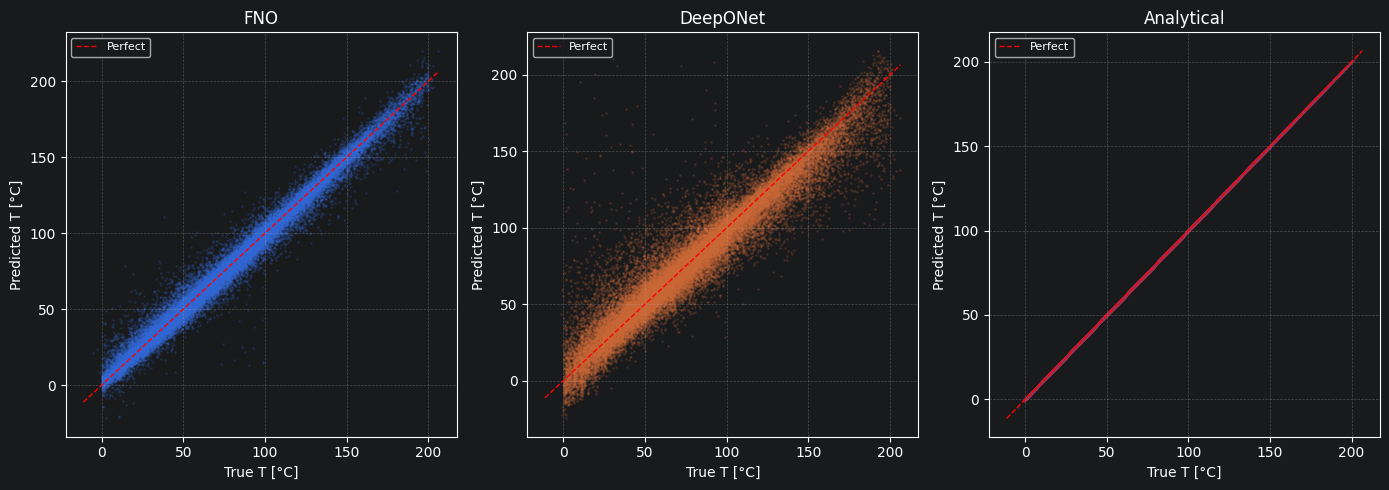

In [15]:
# --- Predicted vs True scatter: all three models ---
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
rng_s = np.random.default_rng(1)

for ax, pred, true, title, color in [
    (axes[0], fno_pred_C,  fno_true_C,  'FNO',        'C0'),
    (axes[1], don_pred_C,  don_true_C,  'DeepONet',   'C1'),
    (axes[2], ana_pred_C,  ana_true_C,  'Analytical', 'C2'),
]:
    flat_p = pred.ravel(); flat_t = true.ravel()
    idx = rng_s.choice(len(flat_p), size=min(40_000, len(flat_p)), replace=False)
    lim = (flat_t.min(), flat_t.max())
    ax.scatter(flat_t[idx], flat_p[idx], s=1, alpha=0.15, color=color, rasterized=True)
    ax.plot(lim, lim, 'r--', lw=1, label='Perfect')
    ax.set_xlabel('True T [°C]'); ax.set_ylabel('Predicted T [°C]')
    ax.set_title(title); ax.legend(fontsize=8); ax.grid(True, ls='--', alpha=0.35)

plt.tight_layout()
plt.savefig(OUT_DIR / 'heat2d_scatter.png', dpi=120)
plt.show()

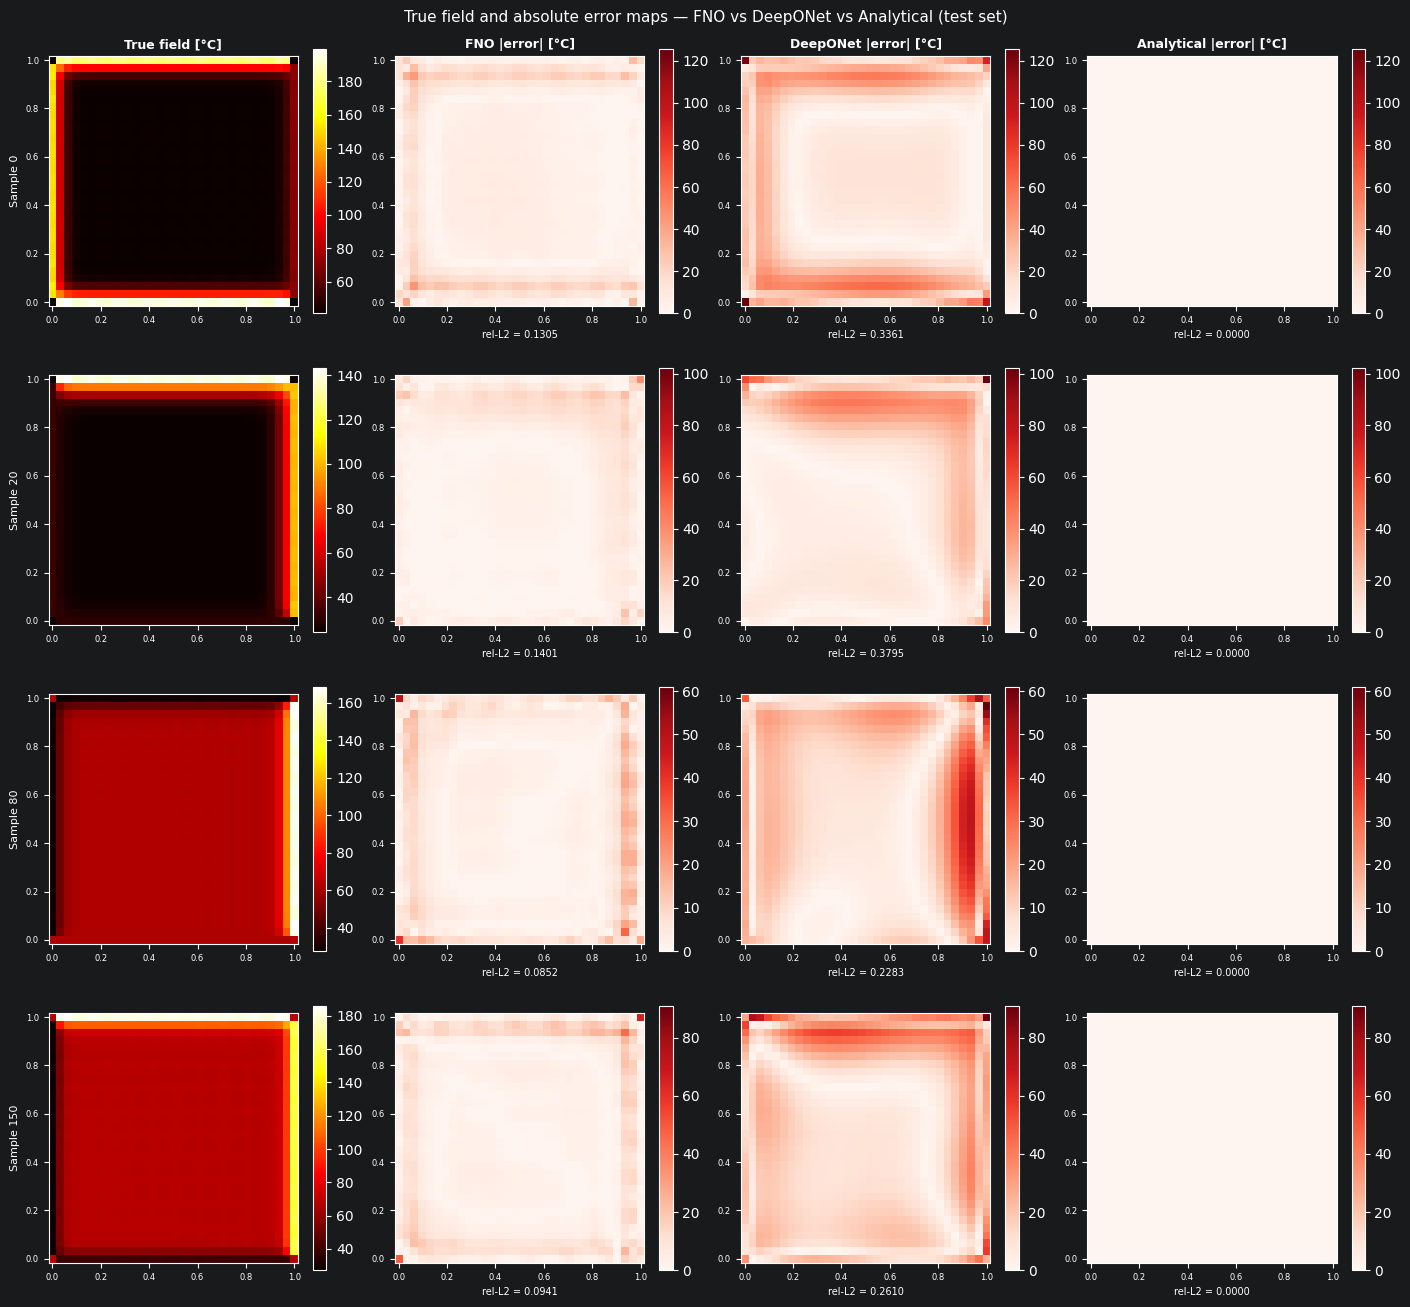

In [16]:
# --- Field comparison: True | FNO error | DON error | Analytical error ---
# Columns: ground truth + one absolute-error map per model (same colour scale per row)
sample_idx = [0, 20, 80, 150]
x_vis = np.linspace(0, 1, NX)
y_vis = np.linspace(0, 1, NY)

fig, axes = plt.subplots(len(sample_idx), 4, figsize=(14, 13), layout='constrained')
col_labels = ['True field [°C]',
              'FNO |error| [°C]',
              'DeepONet |error| [°C]',
              'Analytical |error| [°C]']
for ax, lbl in zip(axes[0], col_labels):
    ax.set_title(lbl, fontsize=9, fontweight='bold')

for row, si in enumerate(sample_idx):
    true  = fno_true_C[si]
    f_err = np.abs(fno_pred_C[si] - true)
    d_err = np.abs(don_pred_C[si] - true)
    a_err = np.abs(ana_pred_C[si] - true)
    emax  = max(f_err.max(), d_err.max(), a_err.max())

    im_t = axes[row, 0].pcolormesh(x_vis, y_vis, true.T,
                                    cmap='hot', shading='auto')
    fig.colorbar(im_t, ax=axes[row, 0], shrink=0.9)

    for col, (err, rl) in enumerate([(f_err, fno_rel_all[si]),
                                      (d_err, don_rel_all[si]),
                                      (a_err, ana_rel_all[si])], start=1):
        im = axes[row, col].pcolormesh(x_vis, y_vis, err.T,
                                        cmap='Reds', vmin=0, vmax=emax, shading='auto')
        fig.colorbar(im, ax=axes[row, col], shrink=0.9)
        axes[row, col].set_xlabel(f'rel-L2 = {rl:.4f}', fontsize=7)

    axes[row, 0].set_ylabel(f'Sample {si}', fontsize=8)
    for ax in axes[row]:
        ax.set_aspect('equal'); ax.tick_params(labelsize=6)

fig.suptitle('True field and absolute error maps — FNO vs DeepONet vs Analytical (test set)',
             fontsize=11)
plt.savefig(OUT_DIR / 'heat2d_field_comparison.png', dpi=120)
plt.show()

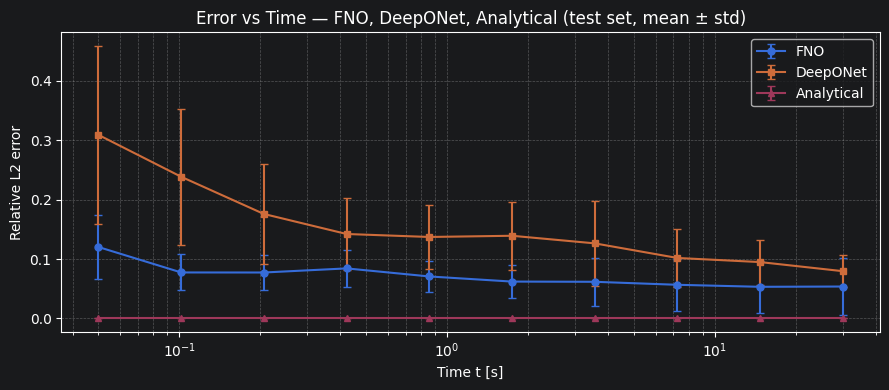

In [17]:
# --- Relative L2 error vs time: all three models ---
test_t = test_df["t"].values

fig, ax = plt.subplots(figsize=(9, 4))
for label, rel_all, color, marker in [
    ('FNO',        fno_rel_all, 'C0', 'o'),
    ('DeepONet',   don_rel_all, 'C1', 's'),
    ('Analytical', ana_rel_all, 'C2', '^'),
]:
    unique_t  = np.unique(test_t)
    mean_err  = [rel_all[test_t == t].mean() for t in unique_t]
    std_err   = [rel_all[test_t == t].std()  for t in unique_t]
    ax.errorbar(unique_t, mean_err, yerr=std_err, marker=marker, ms=5,
                lw=1.5, capsize=3, label=label, color=color)

ax.set_xscale('log')
ax.set_xlabel('Time t [s]'); ax.set_ylabel('Relative L2 error')
ax.set_title('Error vs Time — FNO, DeepONet, Analytical (test set, mean ± std)')
ax.legend(); ax.grid(True, which='both', ls='--', alpha=0.4)
plt.tight_layout()
plt.savefig(OUT_DIR / 'heat2d_error_vs_time.png', dpi=120)
plt.show()